
ITEM (a)
S_load       = 200.000 kVA
fp atual     = 0.650 indutivo
fp desejado  = 0.980 indutivo
P_load       = 130.000 kW
Q atual      = 151.987 kVAr
Q desejado   = 26.398 kVAr
Q compensado = 125.589 kVAr
C_pfc        = 0.917729 uF

PARÂMETROS DA CARGA
Corrente fundamental = 18.1818 A
P_load               = 130000.00 W
Q_load               = 151986.84 var
R_load               = 393.250000 ohm
L_load               = 1.21955180 H

FREQUÊNCIA DE RESSONÂNCIA
Maior |Z_eq| = 12618.128034 ohm
Ordem harmônica de ressonância = 27
Frequência de ressonância = 1620.00 Hz

ITEM (b)
C_pfc                  = 0.917729 uF
Frequência de sintonia = 1620.00 Hz
L_pfc                  = 10.517091 mH
R_pfc                  = 2.141019 ohm
Fator de qualidade     = 50

ITEM (c)
THD antes do filtro = 0.078950 %
THD após o filtro  = 0.022750 %

RESULTADOS POR HARMÔNICA
 h       |Z_before|       |Z_after|     |V_before|pu     |V_after|pu
------------------------------------------------------------
 2           8.

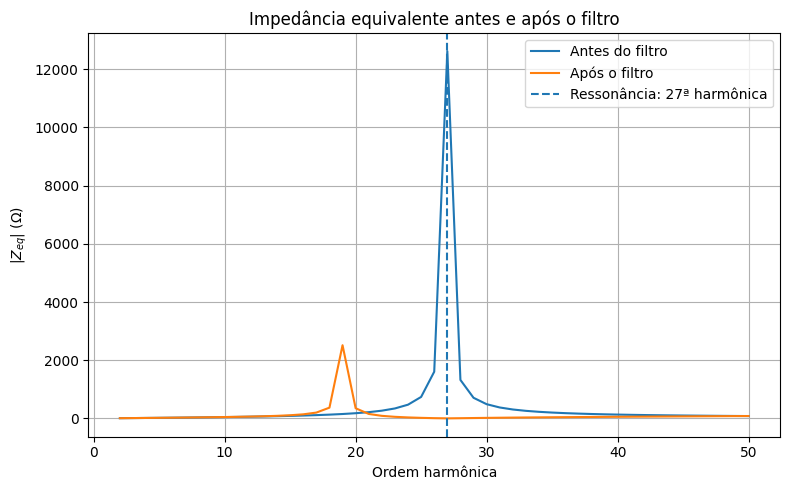

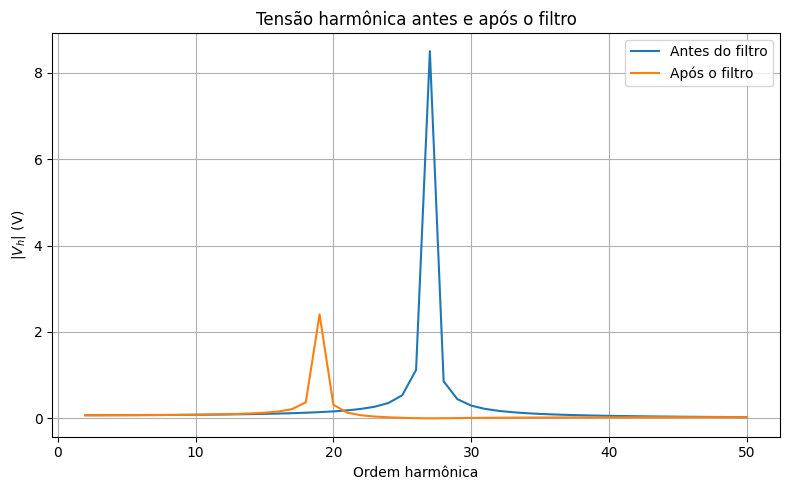

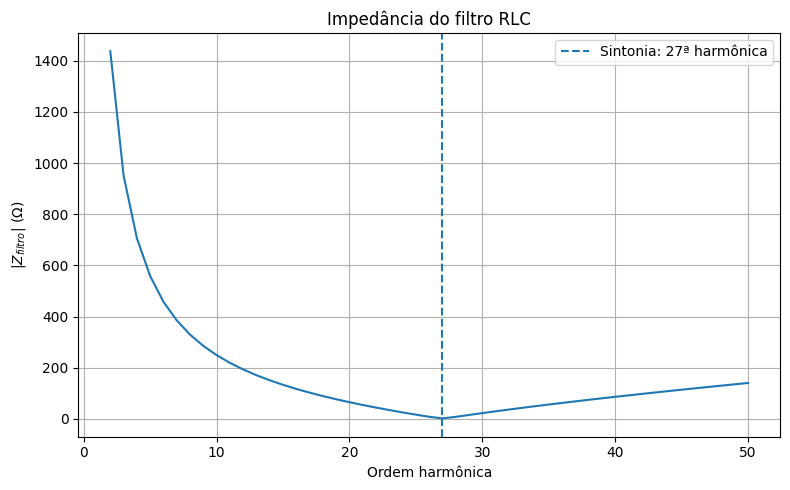

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# Trabalho 02 - Análise Harmônica - Juan Peralta
# ============================================================


plt.close('all')


# ============================================================
# Parâmetros do sistema
# ============================================================

f_rated = 60.0
V_rated = 11e3
L_feed = 0.0107
R_feed = 0.001

S_load = 200e3
pf = 0.65
pf_target = 0.98

type_load = 1
K = 0.20

w_rated = 2 * np.pi * f_rated


# Potência ativa
P_load = pf * S_load

# Potência reativa atual
Q_load = np.sqrt( S_load**2 - P_load**2 )

# Potência reativa correspondente ao fator de potência desejado
Q_target = P_load * np.tan( np.arccos(pf_target))

# Potência reativa que deve ser compensada
Q_pfc = Q_load - Q_target


# ============================================================
# Cálculo da capacitância do banco de acordo com slide
#
# Para banco conectado em Delta:
#
# Q_pfc = 3 * w * C_pfc * V_rated^2
#
# Portanto:
#
# C_pfc = Q_pfc / (3*w*V_rated^2)
# ============================================================

C_pfc = Q_pfc / ( 3 * w_rated * V_rated**2)


print("\n============================================================")
print("ITEM (a)")
print("============================================================")

print(f"S_load       = {S_load/1e3:.3f} kVA")
print(f"fp atual     = {pf:.3f} indutivo")
print(f"fp desejado  = {pf_target:.3f} indutivo")

print(f"P_load       = {P_load/1e3:.3f} kW")
print(f"Q atual      = {Q_load/1e3:.3f} kVAr")
print(f"Q desejado   = {Q_target/1e3:.3f} kVAr")
print(f"Q compensado = {Q_pfc/1e3:.3f} kVAr")

print(f"C_pfc        = {C_pfc*1e6:.6f} uF")


# ============================================================
# Cálculo dos parâmetros da carga
# ============================================================

if type_load == 1:

    # --------------------------------------------------------
    # Carga RX série
    # --------------------------------------------------------

    R_load = P_load * (V_rated**2 /(P_load**2 + Q_load**2))

    L_load = ( Q_load *(V_rated**2 /(P_load**2 + Q_load**2))) / w_rated


elif type_load == 2:

    # --------------------------------------------------------
    # Carga RX paralelo
    # --------------------------------------------------------

    R_load = V_rated**2 / P_load

    L_load = ( V_rated**2 /(w_rated * Q_load))


elif type_load == 3:

    # --------------------------------------------------------
    # Motor de indução + resistiva
    # --------------------------------------------------------

    R_load = (V_rated**2 /((1 - K) * P_load))

    L_load = (V_rated**2 /(8 * 1.2 * K * P_load))


elif type_load == 4:

    # --------------------------------------------------------
    # CIGRE
    # --------------------------------------------------------

    R_load = (V_rated**2 /((1 - K) * P_load))

    L_2 = (0.073 *R_load /w_rated)

    L_load = (V_rated**2 /( w_rated * K * P_load * ( 6.7 * (Q_load / P_load) - 0.74 )))


else:

    raise ValueError(
        "type_load deve ser 1, 2, 3 ou 4"
    )


# ============================================================
# Corrente fundamental da carga
# ============================================================

i_load = abs( S_load /V_rated)


print("\n============================================================")
print("PARÂMETROS DA CARGA")
print("============================================================")

print(f"Corrente fundamental = {i_load:.4f} A")
print(f"P_load               = {P_load:.2f} W")
print(f"Q_load               = {Q_load:.2f} var")
print(f"R_load               = {R_load:.6f} ohm")
print(f"L_load               = {L_load:.8f} H")


# ============================================================
# Espectro da corrente harmônica
#
# Colunas:
# h | magnitude (%) | ângulo (rad)
# ============================================================

i_sp = np.array([
    [1.0000, 100.0000,  0.0],
    [2.0000,  50.0000, -0.2],
    [3.0000,  33.3333, -0.4],
    [4.0000,  25.0000, -0.4],
    [5.0000,  20.0000, -0.4],
    [6.0000,  16.6667, -0.4],
    [7.0000,  14.2857, -0.4],
    [8.0000,  12.5000, -0.4],
    [9.0000,  11.1111, -0.4],
    [10.0000, 10.0000,  -0.4],
    [11.0000, 9.0909,  -0.4],
    [12.0000, 8.3333,  -0.4],
    [13.0000, 7.6923,  -0.4],
    [14.0000, 7.1429,  -0.4],
    [15.0000, 6.6667,  -0.4],
    [16.0000, 6.2500,  -0.4],
    [17.0000, 5.8824,  -0.4],
    [18.0000, 5.5556,  -0.4],
    [19.0000, 5.2632,  -0.4],
    [20.0000, 5.0000,  -0.4],
    [21.0000, 4.7619, -0.4],
    [22.0000, 4.5455, -0.4],
    [23.0000, 4.3478, -0.4],
    [24.0000, 4.1667, -0.4],
    [25.0000, 4.0000, -0.4],
    [26.0000, 3.8462, -0.4],
    [27.0000, 3.7037, -0.4],
    [28.0000, 3.5714, -0.4],
    [29.0000, 3.4483, -0.4],
    [30.0000, 3.3333, -0.4],
    [31.0000, 3.2258, -0.4],
    [32.0000, 3.1250, -0.4],
    [33.0000, 3.0303, -0.4],
    [34.0000, 2.9412, -0.4],
    [35.0000, 2.8571, -0.4],
    [36.0000, 2.7778, -0.4],
    [37.0000, 2.7027, -0.4],
    [38.0000, 2.6316, -0.4],
    [39.0000, 2.5641, -0.4],
    [40.0000, 2.5000, -0.4],
    [41.0000, 2.4390, -0.4],
    [42.0000, 2.3810, -0.4],
    [43.0000, 2.3256, -0.4],
    [44.0000, 2.2727, -0.4],
    [45.0000, 2.2222, -0.4],
    [46.0000, 2.1739, -0.4],
    [47.0000, 2.1277, -0.4],
    [48.0000, 2.0833, -0.4],
    [49.0000, 2.0408, -0.4],
    [50.0000, 2.0000,  -0.4],
])


# ============================================================
# Corrente harmônica injetada
#
# Os valores de i_sp[:,1] estão em porcentagem, deveria ser 100 porém na aula usamos 100000
# ============================================================

i_inj = (i_sp[:, 1] *i_load /100000)


# ============================================================
# Vetores para os harmônicos
# ============================================================

harmonics = np.arange(2, 51)

X_cap = np.zeros(51, dtype=complex)
X_ind = np.zeros(51, dtype=complex)
X_feed = np.zeros(51, dtype=complex)

Adm_eq = np.zeros(51, dtype=complex)
Z_eq = np.zeros(51, dtype=complex)
V_harm = np.zeros(51, dtype=complex)


# ============================================================
# Cálculo da impedância equivalente
#
# O capacitor antigo de 5.4 uF foi retirado.
#
# O novo C_pfc calculado no item (a) é utilizado aqui
# para determinar a frequência na qual |Z_eq| é máximo.
# ============================================================

for h_an in harmonics:

    w = (2 * np.pi * f_rated *h_an)


    # --------------------------------------------------------
    # Reatância capacitiva
    # --------------------------------------------------------

    X_cap[h_an] = ( 1 /(1j * w * C_pfc))


    # --------------------------------------------------------
    # Reatância indutiva da carga
    # --------------------------------------------------------

    X_ind[h_an] = ( 1j * w *L_load)


    # --------------------------------------------------------
    # Impedância da rede
    # --------------------------------------------------------

    X_feed[h_an] = (1j *w *L_feed)


    # --------------------------------------------------------
    # Admitância equivalente
    # --------------------------------------------------------

    if type_load == 1:

        Adm_eq[h_an] = ( 1 / X_cap[h_an] +1 / ( R_load + X_ind[h_an] ) + 1 / ( X_feed[h_an] + R_feed ) )


    elif type_load == 4:

        Adm_eq[h_an] = ( 1 / X_cap[h_an]+ 1 / X_ind[h_an] +1 / ( R_load + 1j * w * L_2)+ 1 / ( X_feed[h_an] + R_feed ))


    elif type_load == 2:

        Adm_eq[h_an] = ( 1 / X_cap[h_an] + 1 / X_ind[h_an] +1 / R_load+1 / (  X_feed[h_an] + R_feed ) )


    else:

        raise ValueError(
            "O código não define Adm_eq para type_load = 3."
        )


    # --------------------------------------------------------
    # Impedância equivalente
    # --------------------------------------------------------

    Z_eq[h_an] = ( 1 / Adm_eq[h_an] )


    # --------------------------------------------------------
    # Tensão harmônica
    # --------------------------------------------------------

    V_harm[h_an] = ( Z_eq[h_an] *i_inj[h_an - 1])


# ============================================================
# Frequência de ressonância
#
# A frequência é definida pelo maior valor de |Z_eq|.
# ============================================================

freq_res_index = np.argmax(np.abs( Z_eq[harmonics]))

freq_res_h = harmonics[freq_res_index]

freq_res = (freq_res_h *f_rated)

Z_max = np.abs(Z_eq[freq_res_h])


print("\n============================================================")
print("FREQUÊNCIA DE RESSONÂNCIA")
print("============================================================")

print(
    f"Maior |Z_eq| = {Z_max:.6f} ohm"
)

print(
    f"Ordem harmônica de ressonância = "
    f"{freq_res_h}"
)

print(
    f"Frequência de ressonância = "
    f"{freq_res:.2f} Hz"
)



# Cálculo da indutância do filtro
#
# f_res = 1 / (2*pi*sqrt(L*C))
#
# L = 1 / ((2*pi*f_res)^2*C)
# ============================================================

L_pfc = 1 / ((2 * np.pi * freq_res)**2 *C_pfc)


# ============================================================
# Cálculo da resistência do filtro
#
# Fator de qualidade:
#
# Q_f = sqrt(L/C) / R
#
# Portanto:
#
# R = sqrt(L/C) / Q_f
# ============================================================

q_f = 50

R_pfc = (np.sqrt(L_pfc /C_pfc) / q_f)


print("\n============================================================")
print("ITEM (b)")
print("============================================================")

print(
    f"C_pfc                  = "
    f"{C_pfc*1e6:.6f} uF"
)

print(
    f"Frequência de sintonia = "
    f"{freq_res:.2f} Hz"
)

print(
    f"L_pfc                  = "
    f"{L_pfc*1e3:.6f} mH"
)

print(
    f"R_pfc                  = "
    f"{R_pfc:.6f} ohm"
)

print(
    f"Fator de qualidade     = "
    f"{q_f}"
)



# ANÁLISE APÓS A INSERÇÃO DO FILTRO RLC
#
# O filtro é composto por:
#
# R_pfc + L_pfc + C_pfc em série.
# ============================================================

Z_eq_after = np.zeros(51,dtype=complex)

V_harm_after = np.zeros(51,dtype=complex)


for h_an in harmonics:

    w = (2 * np.pi * f_rated * h_an)


    # --------------------------------------------------------
    # Impedância do filtro RLC série
    # --------------------------------------------------------

    Z_pfc = (R_pfc+1j * w * L_pfc+1 / (1j * w * C_pfc))


    # --------------------------------------------------------
    # Impedância da carga
    # --------------------------------------------------------

    X_ind[h_an] = ( 1j * w *L_load)


    # --------------------------------------------------------
    # Impedância da rede
    # --------------------------------------------------------

    X_feed[h_an] = ( 1j *w * L_feed)


    # --------------------------------------------------------
    # Admitância equivalente
    # --------------------------------------------------------

    if type_load == 1:

        Adm_eq_after = ( 1 / Z_pfc + 1 / (  R_load + X_ind[h_an] ) + 1 / ( X_feed[h_an] +  R_feed ) )


    elif type_load == 4:

        Adm_eq_after = (1 / Z_pfc+1 / X_ind[h_an]+1 / ( R_load +1j * w * L_2 ) + 1 / ( X_feed[h_an] + R_feed ) )


    elif type_load == 2:

        Adm_eq_after = (1 / Z_pfc +1 / X_ind[h_an] +1 / R_load + 1 / (  X_feed[h_an] + R_feed ))


    else:

        raise ValueError(
            "O código não define Adm_eq para type_load = 3."
        )


    # --------------------------------------------------------
    # Impedância equivalente após o filtro
    # --------------------------------------------------------

    Z_eq_after[h_an] = ( 1 /Adm_eq_after)


    # --------------------------------------------------------
    # Tensão harmônica após o filtro
    # --------------------------------------------------------

    V_harm_after[h_an] = ( Z_eq_after[h_an] * i_inj[h_an - 1])


# ============================================================
# THD ANTES E APÓS O FILTRO
# ============================================================

V_harm_pu = ( V_harm / V_rated)

V_harm_after_pu = (V_harm_after /V_rated)


# ------------------------------------------------------------
# THD antes
# ------------------------------------------------------------

thd_before = ( 100 *np.sqrt( np.sum(np.abs( V_harm_pu[harmonics])**2)))


# ------------------------------------------------------------
# THD após
# ------------------------------------------------------------

thd_after = (100 *np.sqrt(np.sum( np.abs(V_harm_after_pu[harmonics] )**2)))



print("\n============================================================")
print("ITEM (c)")
print("============================================================")

print(
    f"THD antes do filtro = "
    f"{thd_before:.6f} %"
)

print(
    f"THD após o filtro  = "
    f"{thd_after:.6f} %"
)



# ============================================================
# GRÁFICO 1
# IMPEDÂNCIA EQUIVALENTE ANTES E APÓS O FILTRO
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    harmonics,
    np.abs(
        Z_eq[harmonics]
    ),
    label="Antes do filtro"
)

plt.plot(
    harmonics,
    np.abs(
        Z_eq_after[harmonics]
    ),
    label="Após o filtro"
)

plt.axvline(
    freq_res_h,
    linestyle="--",
    label=(
        f"Ressonância: "
        f"{freq_res_h}ª harmônica"
    )
)

plt.xlabel("Ordem harmônica")
plt.ylabel(r"$|Z_{eq}|$ ($\Omega$)")
plt.title(
    "Impedância equivalente antes e após o filtro"
)

plt.grid(True)
plt.legend()
plt.tight_layout()


# ============================================================
# GRÁFICO 2
# TENSÃO HARMÔNICA ANTES E APÓS O FILTRO
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    harmonics,
    np.abs(
        V_harm[harmonics]
    ),
    label="Antes do filtro"
)

plt.plot(
    harmonics,
    np.abs(
        V_harm_after[harmonics]
    ),
    label="Após o filtro"
)

plt.xlabel("Ordem harmônica")
plt.ylabel(r"$|V_h|$ (V)")
plt.title(
    "Tensão harmônica antes e após o filtro"
)

plt.grid(True)
plt.legend()
plt.tight_layout()


# ============================================================
# GRÁFICO 3
# IMPEDÂNCIA DO FILTRO RLC
# ============================================================

Z_pfc_all = np.zeros(
    51,
    dtype=complex
)


for h_an in harmonics:

    w = (
        2 *
        np.pi *
        f_rated *
        h_an
    )

    Z_pfc_all[h_an] = (
        R_pfc
        +
        1j * w * L_pfc
        +
        1 / (1j * w * C_pfc)
    )


plt.figure(figsize=(8, 5))

plt.plot(
    harmonics,
    np.abs(
        Z_pfc_all[harmonics]
    )
)

plt.axvline(
    freq_res_h,
    linestyle="--",
    label=(
        f"Sintonia: "
        f"{freq_res_h}ª harmônica"
    )
)

plt.xlabel("Ordem harmônica")
plt.ylabel(r"$|Z_{filtro}|$ ($\Omega$)")
plt.title(
    "Impedância do filtro RLC"
)

plt.grid(True)
plt.legend()
plt.tight_layout()


# ============================================================
# RESULTADOS POR HARMÔNICA
# ============================================================

print("\n============================================================")
print("RESULTADOS POR HARMÔNICA")
print("============================================================")

print(
    " h       |Z_before|       |Z_after|     "
    "|V_before|pu     |V_after|pu"
)

print(
    "------------------------------------------------------------"
)


for h in harmonics:

    print(

        f"{h:2d}       "

        f"{abs(Z_eq[h]):12.6f}       "

        f"{abs(Z_eq_after[h]):12.6f}       "

        f"{abs(V_harm_pu[h]):12.6e}       "

        f"{abs(V_harm_after_pu[h]):12.6e}"

    )


# ============================================================
# RESUMO FINAL
# ============================================================

print("\n============================================================")
print("RESUMO FINAL")
print("============================================================")

print(
    f"Potência aparente      = "
    f"{S_load/1e3:.3f} kVA"
)

print(
    f"Fator de potência atual= "
    f"{pf:.3f}"
)

print(
    f"Fator de potência alvo = "
    f"{pf_target:.3f}"
)

print(
    f"P_load                 = "
    f"{P_load/1e3:.3f} kW"
)

print(
    f"Q_load                 = "
    f"{Q_load/1e3:.3f} kVAr"
)

print(
    f"Q_compensado           = "
    f"{Q_pfc/1e3:.3f} kVAr"
)

print(
    f"C_pfc                  = "
    f"{C_pfc*1e6:.6f} uF"
)

print(
    f"Frequência ressonante  = "
    f"{freq_res:.2f} Hz"
)

print(
    f"Harmônica de sintonia  = "
    f"{freq_res_h}ª"
)

print(
    f"L_pfc                  = "
    f"{L_pfc*1e3:.6f} mH"
)

print(
    f"R_pfc                  = "
    f"{R_pfc:.6f} ohm"
)

print(
    f"THD antes              = "
    f"{thd_before:.6f} %"
)

print(
    f"THD após               = "
    f"{thd_after:.6f} %"
)




# ============================================================
# Mostrar gráficos
# ============================================================

plt.show()